In [1]:
import tensorflow as tf
import keras_cv
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import os

C:\Users\Aanchal Gupta\Desktop\Knee X-ray Images\imageclassification\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Set paths (change as per your folder structure)
train_dir = r"C:\Users\Aanchal Gupta\Desktop\Knee X-ray Images\processed_data_70_20_10\train"
val_dir = r"C:\Users\Aanchal Gupta\Desktop\Knee X-ray Images\processed_data_70_20_10\val"
test_dir = r"C:\Users\Aanchal Gupta\Desktop\Knee X-ray Images\processed_data_70_20_10\test"
batch_size = 32
img_size = (224, 224)
num_classes = 5
class_names = ['0Normal', '1Doubtful', '2Mild', '3Moderate', '4Severe']  

In [3]:
# Load datasets
train_ds = tf.keras.preprocessing.image_dataset_from_directory(train_dir, image_size=img_size, batch_size=batch_size)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(val_dir, image_size=img_size, batch_size=batch_size)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(test_dir, image_size=img_size, batch_size=batch_size, shuffle=False)


Found 1149 files belonging to 5 classes.
Found 333 files belonging to 5 classes.
Found 168 files belonging to 5 classes.


In [4]:
# Prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [5]:
import tensorflow_hub as hub
import tensorflow as tf
from tensorflow.keras import layers, models, Input

# Load ViT feature extractor
vit_url = "https://tfhub.dev/sayakpaul/vit_b16_fe/1"
vit_layer = hub.KerasLayer(vit_url, trainable=False)

# Functional API
inputs = Input(shape=(224, 224, 3))
x = tf.keras.layers.Rescaling(1./255)(inputs)  # Normalize pixel values
x = tf.keras.layers.Lambda(lambda img: vit_layer(img))(x)  # Wrap in Lambda
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(5, activation='softmax')(x)

model = models.Model(inputs=inputs, outputs=outputs)

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda (Lambda)                      │ (None, 768)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          98,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 99,077 (387.02 KB)

 Trainable params: 99,077 (387.02 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Callbacks
log_dir = "training_logs"
tensorboard_cb = tf.keras.callbacks.TensorBoard(log_dir=log_dir)
#earlystop_cb = tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)


In [7]:
# Train
history = model.fit(train_ds, validation_data=val_ds, epochs=30, callbacks=[tensorboard_cb])

Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 275s 8s/step - accuracy: 0.3189 - loss: 2.4552 - val_accuracy: 0.6006 - val_loss: 1.1019
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 448s 13s/step - accuracy: 0.5488 - loss: 1.1265 - val_accuracy: 0.5916 - val_loss: 0.9913
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 476s 13s/step - accuracy: 0.5999 - loss: 0.9936 - val_accuracy: 0.6517 - val_loss: 0.9003
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 473s 13s/step - accuracy: 0.6828 - loss: 0.8799 - val_accuracy: 0.6607 - val_loss: 0.8528
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 477s 13s/step - accuracy: 0.6714 - loss: 0.8355 - val_accuracy: 0.6697 - val_loss: 0.8206
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 468s 13s/step - accuracy: 0.6938 - loss: 0.7884 - val_accuracy: 0.6577 - val_loss: 0.8008
Epoch 7/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 465s 13s/step - accuracy: 0.7056 - loss: 0.7312 - val_accuracy: 0.6727 - val_loss: 0.8392
Epoch 8/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 461s 13s/step - accuracy: 0.7002 - loss: 0.7530 - val_accuracy: 0.6

6/6 ━━━━━━━━━━━━━━━━━━━━ 57s 9s/step
              precision    recall  f1-score   support

     0Normal       0.90      0.83      0.86        52
   1Doubtful       0.68      0.83      0.75        48
       2Mild       0.85      0.46      0.59        24
   3Moderate       0.81      0.91      0.86        23
     4Severe       0.73      0.76      0.74        21

    accuracy                           0.78       168
   macro avg       0.79      0.76      0.76       168
weighted avg       0.79      0.78      0.78       168

AUROC for 0Normal: 0.9629
AUROC for 1Doubtful: 0.9234
AUROC for 2Mild: 0.9271
AUROC for 3Moderate: 0.9892
AUROC for 4Severe: 0.9686


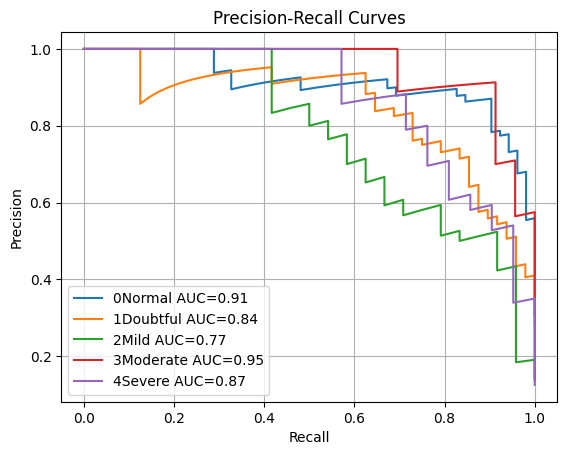

In [8]:
# Predict
y_true = np.concatenate([y.numpy() for x, y in test_ds])
y_probs = model.predict(test_ds)
y_pred = np.argmax(y_probs, axis=1)

# Classification report
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

# AUROC per class
y_true_onehot = tf.keras.utils.to_categorical(y_true, num_classes=num_classes)
auroc = roc_auc_score(y_true_onehot, y_probs, average=None)
for idx, auc_val in enumerate(auroc):
    print(f"AUROC for {class_names[idx]}: {auc_val:.4f}")

# AUPRC per class
for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(y_true_onehot[:, i], y_probs[:, i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"{class_names[i]} AUC={pr_auc:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.grid(True)
plt.show()


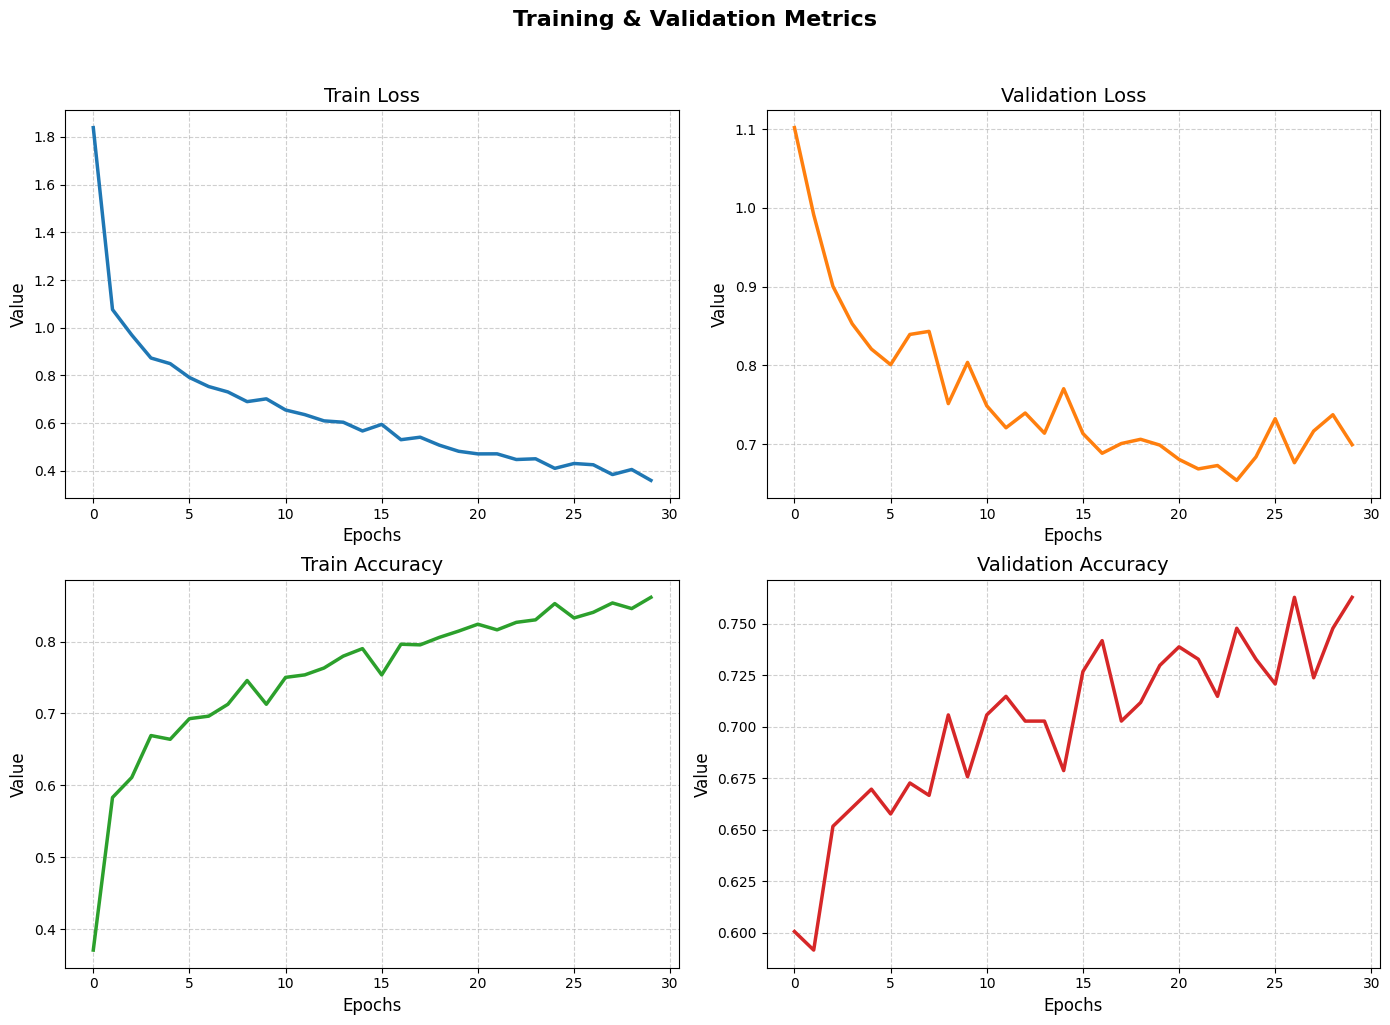

In [9]:
import matplotlib.pyplot as plt

def plot_history(history):
    metrics = {
        'Train Loss': history.history['loss'],
        'Validation Loss': history.history['val_loss'],
        'Train Accuracy': history.history['accuracy'],
        'Validation Accuracy': history.history['val_accuracy']
    }

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
   
    
    plt.figure(figsize=(14, 10))
    
    for i, (title, data) in enumerate(metrics.items(), 1):
        plt.subplot(2, 2, i)
        plt.plot(data, color=colors[i-1], linewidth=2.5)
        plt.title(title, fontsize=14)
        plt.xlabel('Epochs', fontsize=12)
        plt.ylabel('Value', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.xticks(fontsize=10)
        plt.yticks(fontsize=10)
    
    plt.suptitle("Training & Validation Metrics", fontsize=16, fontweight='bold', y=1.02)
    plt.subplots_adjust(top=0.92)
    plt.show()

# Call the function with your model history
plot_history(history)


6/6 ━━━━━━━━━━━━━━━━━━━━ 49s 8s/step


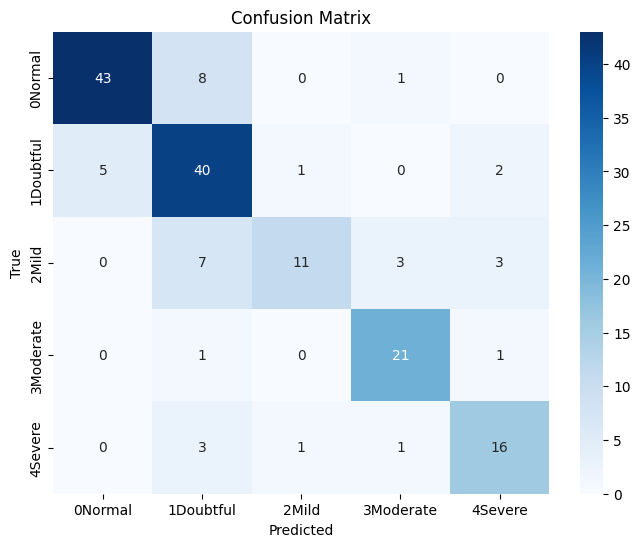

Classification Report:
              precision    recall  f1-score   support

     0Normal       0.90      0.83      0.86        52
   1Doubtful       0.68      0.83      0.75        48
       2Mild       0.85      0.46      0.59        24
   3Moderate       0.81      0.91      0.86        23
     4Severe       0.73      0.76      0.74        21

    accuracy                           0.78       168
   macro avg       0.79      0.76      0.76       168
weighted avg       0.79      0.78      0.78       168

Specificity for class 0Normal: 0.9569
Specificity for class 1Doubtful: 0.8417
Specificity for class 2Mild: 0.9861
Specificity for class 3Moderate: 0.9655
Specificity for class 4Severe: 0.9592
AUROC for class 0Normal: 0.9629
AUROC for class 1Doubtful: 0.9234
AUROC for class 2Mild: 0.9271
AUROC for class 3Moderate: 0.9892
AUROC for class 4Severe: 0.9686

AUPRC (Area under Precision-Recall Curve):
AUPRC for class 0Normal: 0.9112
AUPRC for class 1Doubtful: 0.8442
AUPRC for class 2Mild: 0

In [10]:
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize

# 1. True and predicted labels
y_true = []
for images, labels in test_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# 3. Classification Report: Accuracy, Precision, Recall, F1
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# 4. Specificity Calculation
specificity = []
for i in range(num_classes):
    tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
    fp = cm[:, i].sum() - cm[i, i]
    specificity_i = tn / (tn + fp) if (tn + fp) > 0 else 0
    specificity.append(specificity_i)

for i, s in enumerate(specificity):
    print(f"Specificity for class {class_names[i]}: {s:.4f}")

# 5. AUROC (One-vs-Rest)
y_true_bin = label_binarize(y_true, classes=range(num_classes))
try:
    aucs = roc_auc_score(y_true_bin, y_pred_probs, average=None)
    for i, auc_val in enumerate(aucs):
        print(f"AUROC for class {class_names[i]}: {auc_val:.4f}")
except ValueError:
    print("Not enough samples per class to calculate AUROC.")

# 6. AUPRC (One-vs-Rest)
print("\nAUPRC (Area under Precision-Recall Curve):")
for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_pred_probs[:, i])
    auprc = auc(recall, precision)
    print(f"AUPRC for class {class_names[i]}: {auprc:.4f}")
